# Homework 4 - Question 1: Differential Privacy in Deep Learning

**Course:** Security and Privacy in Machine Learning

**Student Name:** Amirhosein Rezaei

**Student ID:** 401105989

---

## Overview
In this advanced assignment, you will go beyond basic DP implementation. Unlike standard tutorials that treat the optimizer as a black box, here you will:

1.  **Analyze Privacy Accounting:** Compare the theoretical bounds of Basic Composition vs. Rényi Differential Privacy (RDP).
2.  **Engineer for Speed:** Implement vectorized per-sample gradients using `torch.func` (formerly functorch) and benchmark it against naive loops.
3.  **Ensure Convergence:** Use **DP Fine-Tuning** on a pre-trained ResNet (instead of training from scratch) to observe actual utility-privacy tradeoffs.
4.  **Conduct Hyperparameter Studies:** Systematically analyze the effect of **Epsilon ($\epsilon$)** and **Clipping Norm ($C$)** on model performance.
5.  **Attack Your Model:** Perform a comparative **Membership Inference Attack (MIA)** to demonstrate the defense mechanism in action.
6.  **(Optional) Federated DP:** Implement User-Level Differential Privacy in a simulated Federated Learning setting.

In [1]:
!pip install opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 5.4 MB/s eta 0:00:00


In [2]:
!pip install scikit-learn

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
from torch.func import functional_call, vmap, grad
import time
from opacus.accountants import RDPAccountant
from opacus.accountants.utils import get_noise_multiplier
import copy
from sklearn.metrics import roc_curve, auc

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Part 1: Advanced Privacy Accounting
Standard composition theorems are often too loose for Deep Learning.

**The Task:**
1.  Calculate the noise $\sigma$ required for a target $\epsilon$ using **Rényi Differential Privacy (RDP)**.
2.  Visualize the accumulation of $\epsilon$ over epochs to understand why RDP is necessary.

In [4]:
def compare_accountants(target_epsilon, target_delta, sample_rate, epochs):
    """
    Calculates the required noise multiplier and visualizes privacy budget consumption.
    """
    # TODO: 1. Use `get_noise_multiplier` from Opacus to find the required sigma
    sigma_rdp = get_noise_multiplier(
        target_epsilon=target_epsilon,
        target_delta=target_delta,
        sample_rate=sample_rate,
        epochs=epochs,
        accountant="rdp"
    )

    print(f"Required Noise Multiplier (RDP): {sigma_rdp:.4f}")


    # TODO: 2. Visualize RDP accumulation
    accountant = RDPAccountant()
    eps_history = []

    for epoch in range(epochs):
        accountant.step(
            noise_multiplier=sigma_rdp,
            sample_rate=sample_rate
        )
        eps = accountant.get_epsilon(target_delta)
        eps_history.append(eps)

    # Plot eps_history vs epochs
    plt.figure()
    plt.plot(range(1, epochs+1), eps_history)
    plt.xlabel("Epoch")
    plt.ylabel("Epsilon")
    plt.title("RDP Privacy Budget Accumulation")
    plt.grid(True)
    plt.show()

    return sigma_rdp

### Question 1: Accounting Analysis
Observe the plot you generated above. How does the privacy budget $\epsilon$ grow with respect to the number of epochs (or steps) in the RDP accounting method? If we had used Basic Composition (where $\epsilon_{total} = \sum \epsilon_i$), how would the shape of the curve differ?

**Your Answer:**
The privacy budget epsilon grows approximately sub linearly with the number of epochs under RDP accounting. At first it increases faster but growth slows because of tighter composition bounds and RDP provides tighter bounds. If we used Basic Composition epsilon would grow linearly with epochs and this would produce a straight line curve and significantly overestimating privacy loss compared to RDP.

## Part 2: Engineering Efficient DP-SGD
Computing gradients for individual samples is the computational bottleneck of DP-SGD.

**The Task:**
Implement `ManualDPSGD` using `torch.func.vmap`. You must **not** use a for-loop over the batch dimension in `compute_per_sample_gradients`.

In [5]:
class ManualDPSGD:
    def __init__(self, model, lr, noise_multiplier, max_grad_norm):
        self.model = model
        self.noise_multiplier = noise_multiplier
        self.max_grad_norm = max_grad_norm
        self.params = [p for p in model.parameters() if p.requires_grad]
        self.base_optimizer = optim.SGD(self.params, lr=lr, momentum=0)

    def compute_per_sample_gradients(self, data, targets, loss_fn):
        """
        Computes per-sample gradients efficiently using torch.func.

         1. Define a stateless function `compute_loss_stateless(params, data, target)`
            Hint: Use `functional_call` to apply params to self.model
         2. Use `grad` to get gradients of that function.
         3. Use `vmap` to apply it over the batch dimension (in_dims).
        """

        # TODO: Implement the functional transform logic.
        params_dict = {
            name: param
            for name, param in self.model.named_parameters()
            if param.requires_grad
        }

        def compute_loss_stateless(params, sample, target):
            output = functional_call(self.model, params, (sample.unsqueeze(0),))
            loss = loss_fn(output, target.unsqueeze(0))
            return loss

        grad_fn = grad(compute_loss_stateless)

        per_sample_grads = vmap(
            grad_fn,
            in_dims=(None, 0, 0)
        )(params_dict, data, targets)

        return per_sample_grads

    def clip_and_noise(self, per_sample_grads):
        """
        1. Calculates the L2 norm of gradients for EACH sample (Global Norm).
        2. Clips them to self.max_grad_norm.
        3. Sums them up.
        4. Adds Gaussian noise.
        """
        batch_size = next(iter(per_sample_grads.values())).shape[0]

        total_norms = torch.zeros(batch_size, device=device)

        for g in per_sample_grads.values():
            total_norms += g.view(batch_size, -1).pow(2).sum(dim=1)

        total_norms = torch.sqrt(total_norms)

        clip_factors = (self.max_grad_norm / (total_norms + 1e-6)).clamp(max=1.0)

        summed_noisy_grads = {}

        for name, g in per_sample_grads.items():
            clipped = g * clip_factors.view(-1, *([1]*(g.dim()-1)))
            summed = clipped.sum(dim=0)

            noise = torch.randn_like(summed) * self.noise_multiplier * self.max_grad_norm
            summed_noisy_grads[name] = summed + noise

        return summed_noisy_grads

    def step(self, data, targets, loss_fn):
        self.base_optimizer.zero_grad()

        # 1. Per-sample Grads
        per_sample_grads = self.compute_per_sample_gradients(data, targets, loss_fn)

        # 2. Clip & Noise
        final_grads = self.clip_and_noise(per_sample_grads)

        # 3. Assign grads back to model parameters
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                # Important: Divide by batch size here if your loss_fn was reduction='mean'
                # or if standard SGD expects averaged gradients.
                param.grad = final_grads[name] / data.shape[0]

        # 4. Step
        self.base_optimizer.step()

### Benchmarking
Run the cell below to verify that your `vmap` implementation is faster than a naive loop. If your implementation is correct, `Vectorized Time` should be significantly lower.

In [6]:
def run_benchmark(model, data, targets):
    print("Benchmarking Gradient Computation...")

    # Naive Loop (Baseline)
    start = time.time()
    criterion = nn.CrossEntropyLoss()
    model.zero_grad()
    for i in range(data.shape[0]):
        output = model(data[i:i+1])
        loss = criterion(output, targets[i:i+1])
        loss.backward()
        model.zero_grad()
    end = time.time()
    print(f"Naive Loop Time (Batch {data.shape[0]}): {end - start:.4f}s")

    # Vectorized (Your Implementation)
    dpsgd = ManualDPSGD(model, lr=0.1, noise_multiplier=1.0, max_grad_norm=1.0)
    start = time.time()
    try:
        _ = dpsgd.compute_per_sample_gradients(data, targets, nn.CrossEntropyLoss())
        end = time.time()
        print(f"Vectorized (vmap) Time (Batch {data.shape[0]}): {end - start:.4f}s")
    except Exception as e:
        print(f"Vectorized implementation failed: {e}")

In [7]:
# Create dummy inputs for the benchmark (Batch Size 64, CIFAR-10 image size)
dummy_data = torch.randn(64, 3, 32, 32).to(device)
dummy_targets = torch.randint(0, 10, (64,)).to(device)

# Create a simple dummy model (We use a simple one here just to test the gradient speed)
dummy_model = nn.Sequential(
    nn.Conv2d(3, 16, 3),
    nn.Flatten(),
    nn.Linear(16 * 30 * 30, 10)
).to(device)

# Run the benchmark
run_benchmark(dummy_model, dummy_data, dummy_targets)

Benchmarking Gradient Computation...
Naive Loop Time (Batch 64): 0.8275s
Vectorized (vmap) Time (Batch 64): 0.3048s


## Part 3: Model Setup (DP Fine-Tuning)

Training from scratch with DP is difficult due to gradient noise. We will use **Transfer Learning** by fine-tuning a pre-trained ResNet18.

**The Task:**
1. Load a pre-trained ResNet18.
2. **Freeze** all layers except the final classification head.
3. Replace the final layer to match CIFAR-10 classes (10 outputs).

In [8]:
def get_pretrained_model_for_cifar():
    # TODO: Load ResNet18 with pretrained=True
    model = models.resnet18(pretrained=True)

    # TODO: Freeze all parameters (requires_grad = False)
    for param in model.parameters():
        param.requires_grad = False

    # TODO: Replace the final fully connected layer (model.fc)
    # Ensure the new layer has requires_grad = True
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 10)

    return model.to(device)

def train_model(model, train_loader, optimizer, epochs, is_dp=True):
    model.train()
    # Fix for Fine-Tuning: Force BatchNorm to Eval mode to prevent privacy leakage
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()

    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        correct = 0
        total = 0

        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)

            if is_dp:
                optimizer.step(data, targets, criterion)
            else:
                optimizer.zero_grad()
                output = model(data)
                loss = criterion(output, targets)
                loss.backward()
                optimizer.step()

            # Simple accuracy tracking
            with torch.no_grad():
                outputs = model(data)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        print(f"Epoch {epoch+1}/{epochs} | Acc: {100.*correct/total:.2f}%")
    return 100.*correct/total

## Part 4: Hyperparameter Studies

In Differential Privacy, performance is highly sensitive to hyperparameters. You will now conduct two experiments to understand these trade-offs.

### 4.1. Effect of Privacy Budget ($\epsilon$)
**Goal:** Fix the Clipping Norm ($C=1.0$) and vary the target $\epsilon$. Observe how accuracy improves as you relax the privacy constraint (higher $\epsilon$).

**Task:**
1. Iterate through `epsilons = [0.5, 1.0, 3.0, 8.0]`.
2. For each epsilon, calculate the required $\sigma$, train a new model, and record the final accuracy.
3. Plot **Accuracy vs. Epsilon**.

100%|██████████| 170M/170M [00:02<00:00, 73.9MB/s]


--- Running Epsilon Sweep ---
Training with Epsilon = 0.5...
Required Noise Multiplier (RDP): 4.0234


/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


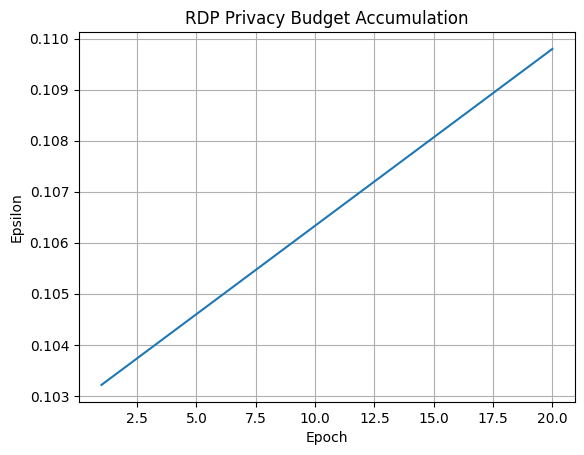

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


Epoch 1/20 | Acc: 28.78%
Epoch 2/20 | Acc: 27.60%
Epoch 3/20 | Acc: 28.20%
Epoch 4/20 | Acc: 33.36%
Epoch 5/20 | Acc: 35.44%
Epoch 6/20 | Acc: 37.18%
Epoch 7/20 | Acc: 40.52%
Epoch 8/20 | Acc: 42.28%
Epoch 9/20 | Acc: 43.06%
Epoch 10/20 | Acc: 44.78%
Epoch 11/20 | Acc: 44.52%
Epoch 12/20 | Acc: 44.66%
Epoch 13/20 | Acc: 45.20%
Epoch 14/20 | Acc: 46.96%
Epoch 15/20 | Acc: 45.94%
Epoch 16/20 | Acc: 45.92%
Epoch 17/20 | Acc: 47.56%
Epoch 18/20 | Acc: 49.18%
Epoch 19/20 | Acc: 48.16%
Epoch 20/20 | Acc: 49.40%
Training with Epsilon = 1.0...
Required Noise Multiplier (RDP): 2.2266


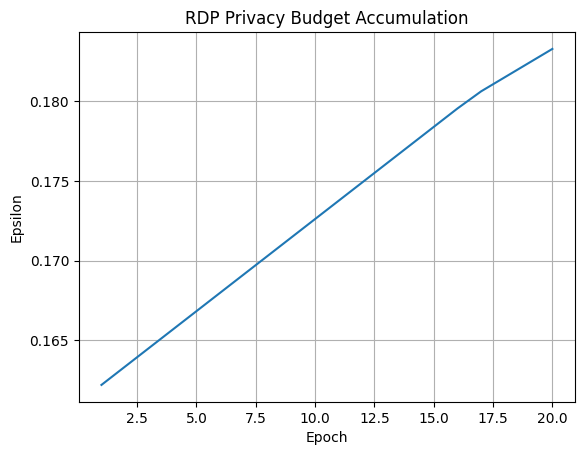

Epoch 1/20 | Acc: 44.10%
Epoch 2/20 | Acc: 46.66%
Epoch 3/20 | Acc: 52.88%
Epoch 4/20 | Acc: 52.00%
Epoch 5/20 | Acc: 53.12%
Epoch 6/20 | Acc: 56.22%
Epoch 7/20 | Acc: 57.12%
Epoch 8/20 | Acc: 57.48%
Epoch 9/20 | Acc: 56.60%
Epoch 10/20 | Acc: 57.30%
Epoch 11/20 | Acc: 56.10%
Epoch 12/20 | Acc: 55.06%
Epoch 13/20 | Acc: 56.32%
Epoch 14/20 | Acc: 56.32%
Epoch 15/20 | Acc: 58.30%
Epoch 16/20 | Acc: 58.42%
Epoch 17/20 | Acc: 58.06%
Epoch 18/20 | Acc: 58.54%
Epoch 19/20 | Acc: 59.20%
Epoch 20/20 | Acc: 59.74%
Training with Epsilon = 3.0...
Required Noise Multiplier (RDP): 1.0522


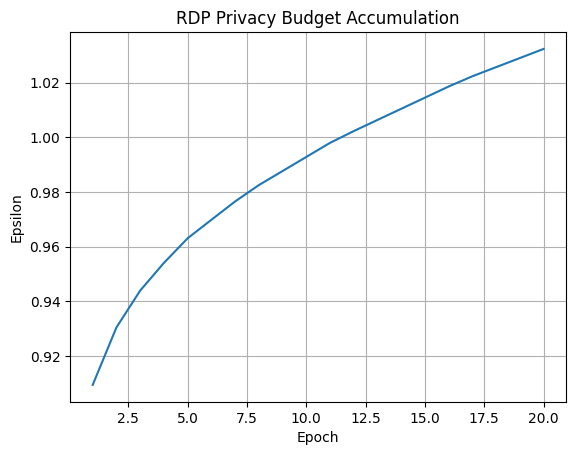

Epoch 1/20 | Acc: 61.16%
Epoch 2/20 | Acc: 68.40%
Epoch 3/20 | Acc: 70.56%
Epoch 4/20 | Acc: 69.72%
Epoch 5/20 | Acc: 69.24%
Epoch 6/20 | Acc: 70.88%
Epoch 7/20 | Acc: 71.66%
Epoch 8/20 | Acc: 71.30%
Epoch 9/20 | Acc: 71.68%
Epoch 10/20 | Acc: 71.92%
Epoch 11/20 | Acc: 71.72%
Epoch 12/20 | Acc: 72.28%
Epoch 13/20 | Acc: 71.74%
Epoch 14/20 | Acc: 72.64%
Epoch 15/20 | Acc: 72.64%
Epoch 16/20 | Acc: 72.54%
Epoch 17/20 | Acc: 73.38%
Epoch 18/20 | Acc: 73.02%
Epoch 19/20 | Acc: 73.48%
Epoch 20/20 | Acc: 73.62%
Training with Epsilon = 8.0...
Required Noise Multiplier (RDP): 0.7019


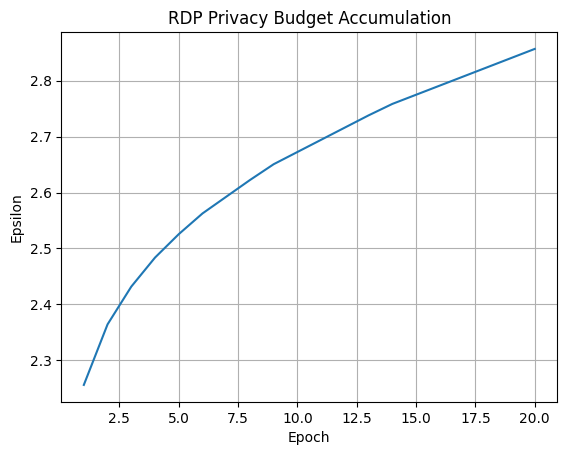

Epoch 1/20 | Acc: 66.46%
Epoch 2/20 | Acc: 76.96%
Epoch 3/20 | Acc: 77.12%
Epoch 4/20 | Acc: 78.26%
Epoch 5/20 | Acc: 78.20%
Epoch 6/20 | Acc: 77.48%
Epoch 7/20 | Acc: 78.76%
Epoch 8/20 | Acc: 79.46%
Epoch 9/20 | Acc: 79.68%
Epoch 10/20 | Acc: 79.22%
Epoch 11/20 | Acc: 79.04%
Epoch 12/20 | Acc: 78.30%
Epoch 13/20 | Acc: 78.88%
Epoch 14/20 | Acc: 79.54%
Epoch 15/20 | Acc: 79.40%
Epoch 16/20 | Acc: 79.40%
Epoch 17/20 | Acc: 79.42%
Epoch 18/20 | Acc: 79.62%
Epoch 19/20 | Acc: 79.46%
Epoch 20/20 | Acc: 79.58%


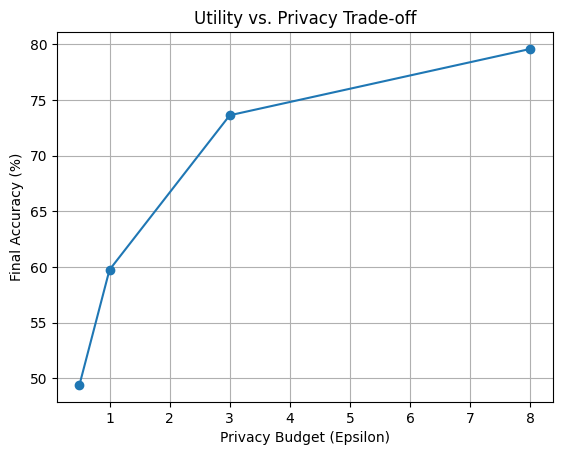

In [9]:
# Common Constants
# TODO: Adjust hyperparameters
BATCH_SIZE = 64
EPOCHS = 20
TARGET_DELTA = 1e-5

import torchvision.models as models

# Data Loading
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
subset_indices = list(range(0, 5000)) # Train on 5000 images
train_subset = torch.utils.data.Subset(trainset, subset_indices)
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_train)
test_loader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)
sample_rate = BATCH_SIZE / len(train_subset)

# --- Experiment 1: Varying Epsilon ---
epsilons = [0.5, 1.0, 3.0, 8.0]
accuracies_eps = []
dp_model = None
best_acc = 0

print("--- Running Epsilon Sweep ---")
for eps in epsilons:
    print(f"Training with Epsilon = {eps}...")

    # TODO: Calculate Sigma for this specific Epsilon
    sigma = compare_accountants(eps, TARGET_DELTA, sample_rate, EPOCHS)

    # TODO: Train Model and compute the final accuracy
    model = get_pretrained_model_for_cifar()
    optimizer = ManualDPSGD(model, lr=1.0,
                             noise_multiplier=sigma,
                             max_grad_norm=1.0)

    acc = train_model(model, train_loader, optimizer, EPOCHS, is_dp=True)
    accuracies_eps.append(acc)

    # TODO: Save a model for Part 5 (one choice is best model)
    if acc > best_acc:
        best_acc = acc
        dp_model = copy.deepcopy(model)


# Plot Accuracy vs Epsilon
plt.figure()
plt.plot(epsilons, accuracies_eps, marker='o')
plt.xlabel('Privacy Budget (Epsilon)')
plt.ylabel('Final Accuracy (%)')
plt.title('Utility vs. Privacy Trade-off')
plt.grid(True)
plt.show()

### 4.2. Effect of Clipping Norm ($C$)
**Goal:** Fix the Privacy Budget ($\\epsilon=3.0$) and vary the Clipping Norm $C$.
Recall that Noise $\propto \sigma \cdot C$.
* **Small $C$:** Low noise variance, but high bias (gradients are crushed).
* **Large $C$:** Low bias, but massive noise variance.

**Task:**
1. Iterate through `clip_norms =  [0.01, 0.05, 0.1, 0.5, 0.7, 1, 1.5, 2, 2.5, 4, 7, 10]`.
2. Train a new model for each $C$ (keeping $\epsilon=3.0$ fixed).
3. Plot **Accuracy vs. Clipping Norm**.

Required Noise Multiplier (RDP): 1.0522


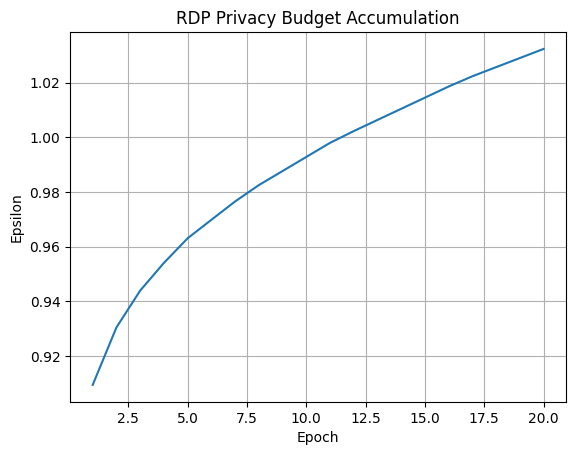


--- Running Clipping Norm Sweep ---
Training with Clip Norm C = 0.01...
Epoch 1/20 | Acc: 13.20%
Epoch 2/20 | Acc: 21.76%
Epoch 3/20 | Acc: 30.00%
Epoch 4/20 | Acc: 37.78%
Epoch 5/20 | Acc: 44.76%
Epoch 6/20 | Acc: 50.50%
Epoch 7/20 | Acc: 54.58%
Epoch 8/20 | Acc: 57.56%
Epoch 9/20 | Acc: 59.34%
Epoch 10/20 | Acc: 62.54%
Epoch 11/20 | Acc: 63.84%
Epoch 12/20 | Acc: 65.30%
Epoch 13/20 | Acc: 67.10%
Epoch 14/20 | Acc: 67.74%
Epoch 15/20 | Acc: 68.64%
Epoch 16/20 | Acc: 69.38%
Epoch 17/20 | Acc: 69.98%
Epoch 18/20 | Acc: 70.12%
Epoch 19/20 | Acc: 71.02%
Epoch 20/20 | Acc: 71.62%
Training with Clip Norm C = 0.05...
Epoch 1/20 | Acc: 30.20%
Epoch 2/20 | Acc: 51.42%
Epoch 3/20 | Acc: 61.50%
Epoch 4/20 | Acc: 67.04%
Epoch 5/20 | Acc: 70.44%
Epoch 6/20 | Acc: 71.14%
Epoch 7/20 | Acc: 73.22%
Epoch 8/20 | Acc: 73.96%
Epoch 9/20 | Acc: 75.52%
Epoch 10/20 | Acc: 75.42%
Epoch 11/20 | Acc: 75.86%
Epoch 12/20 | Acc: 76.22%
Epoch 13/20 | Acc: 77.56%
Epoch 14/20 | Acc: 77.44%
Epoch 15/20 | Acc: 78.46%

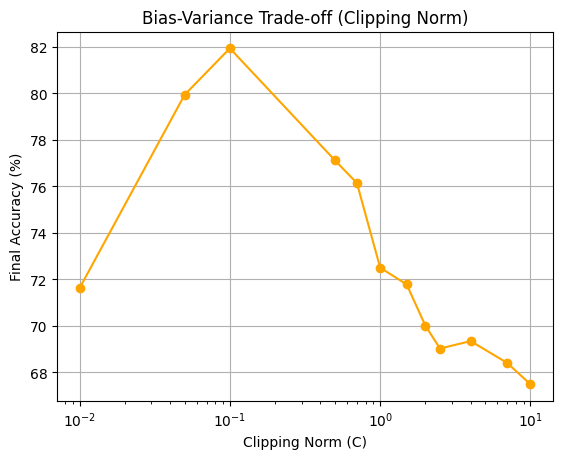

In [10]:
# --- Experiment 2: Varying Clip Norm ---
clip_norms = [0.01, 0.05, 0.1, 0.5, 0.7, 1, 1.5, 2, 2.5, 4, 7, 10]
accuracies_clip = []
FIXED_EPSILON = 3.0

# Calculate sigma ONCE since Epsilon and Epochs are fixed for this experiment
sigma_fixed = compare_accountants(FIXED_EPSILON, TARGET_DELTA, sample_rate, EPOCHS)

print("\n--- Running Clipping Norm Sweep ---")
for C in clip_norms:
    print(f"Training with Clip Norm C = {C}...")

    # TODO: Train Model and compute the final accuracy
    model = get_pretrained_model_for_cifar()
    optimizer = ManualDPSGD(model, lr=1.0,
                             noise_multiplier=sigma_fixed,
                             max_grad_norm=C)

    acc = train_model(model, train_loader, optimizer, EPOCHS, is_dp=True)
    accuracies_clip.append(acc)

# Plot Accuracy vs Clip Norm
plt.figure()
plt.plot(clip_norms, accuracies_clip, marker='o', color='orange')
plt.xscale('log') # Log scale helps visualize orders of magnitude
plt.xlabel('Clipping Norm (C)')
plt.ylabel('Final Accuracy (%)')
plt.title('Bias-Variance Trade-off (Clipping Norm)')
plt.grid(True)
plt.show()

### Question 2: Hyperparameter Analysis
1. **Epsilon Analysis:** Did accuracy increase monotonically with $\epsilon$? At what $\epsilon$ value did utility start to plateau (diminishing returns)?
2. **Clipping Norm Analysis:** Based on your second plot, is there a "sweet spot" for $C$? Explain why performance degrades if $C$ is too small (e.g., 0.1) versus too large (e.g., 10.0).

**Your Answer:**

1. Accuracy generally increases monotonically with epsilon and after epsilon = 3.0 performance improvements begin to plateau so this shows diminishing returns beyond moderate privacy relaxation.

2. There is a sweet spot around C = 0.5–1.5 so if C is too small like 0.1 gradients are crushed so we have high bias and underfitting and if C is too large like 10 noise variance explodes so we have high variance and unstable training so DP is fundamentally a bias-variance tradeoff.

## Part 5: (Optional) Membership Inference Attack
Implement a **Loss-Threshold Attack** to demonstrate the privacy benefits of your DP model.
Use one of the **DP models** from your experiments above and compare it against a non-private baseline.

**The Task:**
1. Train a Non-DP Baseline Model (Standard SGD).
2. Calculate the CrossEntropyLoss for every sample in the Train Set and Test Set for both models.
3. Compute the ROC Curve assuming that `Loss(Member) < Loss(Non-Member)`.
4. Compare the AUC of the Non-DP model (High Risk) vs. the DP model (Low Risk).

--- Training Non-DP Baseline ---
Epoch 1/20 | Acc: 63.68%
Epoch 2/20 | Acc: 81.08%
Epoch 3/20 | Acc: 83.00%
Epoch 4/20 | Acc: 84.72%
Epoch 5/20 | Acc: 85.22%
Epoch 6/20 | Acc: 85.84%
Epoch 7/20 | Acc: 86.90%
Epoch 8/20 | Acc: 86.68%
Epoch 9/20 | Acc: 87.28%
Epoch 10/20 | Acc: 87.42%
Epoch 11/20 | Acc: 87.68%
Epoch 12/20 | Acc: 87.96%
Epoch 13/20 | Acc: 88.24%
Epoch 14/20 | Acc: 88.46%
Epoch 15/20 | Acc: 88.58%
Epoch 16/20 | Acc: 88.68%
Epoch 17/20 | Acc: 89.22%
Epoch 18/20 | Acc: 89.16%
Epoch 19/20 | Acc: 89.20%
Epoch 20/20 | Acc: 89.72%
Running MIA on Non-DP Baseline...
Non-DP Baseline AUC: 0.5222
Running MIA on Best DP Model...
Best DP Model AUC: 0.5212


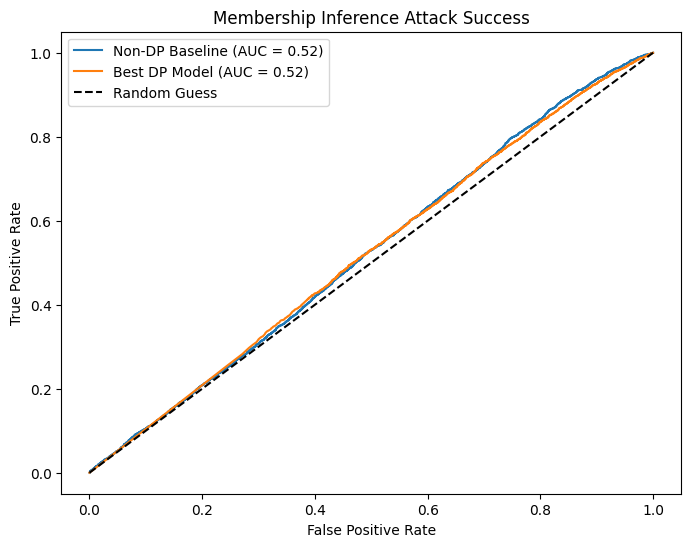

In [11]:
# 1. Train Non-DP Baseline (if not already done)
print("--- Training Non-DP Baseline ---")
base_model = get_pretrained_model_for_cifar()
base_optimizer = optim.SGD(filter(lambda p: p.requires_grad, base_model.parameters()), lr=0.01)
train_model(base_model, train_loader, base_optimizer, EPOCHS, is_dp=False)

# 2. Attack Implementation
def compute_losses(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='none')
    losses = []
    # TODO: Iterate over loader, compute loss per sample, append to list
    with torch.no_grad():
        for data, targets in loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            batch_losses = criterion(outputs, targets)
            losses.extend(batch_losses.cpu().numpy())

    return np.array(losses)

def run_mia_analysis(model, name="Model"):
    print(f"Running MIA on {name}...")
    train_losses = compute_losses(model, train_loader)
    test_losses = compute_losses(model, test_loader)

    # TODO: Implement ROC Curve Calculation
    labels = np.concatenate([np.ones(len(train_losses)),
                             np.zeros(len(test_losses))])

    scores = -np.concatenate([train_losses, test_losses])

    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    print(f"{name} AUC: {roc_auc:.4f}")


# Plot True Positive Rate vs False Positive Rate
plt.figure(figsize=(8, 6))
run_mia_analysis(base_model, "Non-DP Baseline")
if dp_model is not None:
    run_mia_analysis(dp_model, "Best DP Model")
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Membership Inference Attack Success')
plt.legend()
plt.show()

### Question 3: Attack Analysis
Compare the AUC scores of the Non-DP Model and the DP-SGD Model.
1. What does an AUC of ~0.5 (for the DP model) indicate about the adversary's ability to infer membership?
2. Why does the Non-DP model likely have a much higher AUC, even if its test accuracy is similar?

**Your Answer:**
1. In AUC of ~0.5 the attacker performs no better than random guessing so strong privacy protection.

2. The Non-DP model overfits more so we have lower training loss vs test loss so easier membership inference and high AUC.

## Part 6: (Optional) Federated Learning with Differential Privacy

In standard DP-SGD (Part 2), we clipped the gradient of **each sample** (Item-Level DP).
In Federated Learning, we want to protect the contribution of **each client** (User-Level DP). A client might have multiple data points.

**The Protocol (DP-FedAvg):**
1.  **Broadcast:** Server sends global model $\theta_t$ to selected clients.
2.  **Local Training:** Client $k$ trains on their local dataset $D_k$ to get $\theta_k$.
3.  **Compute Update:** $\Delta_k = \theta_k - \theta_t$.
4.  **Clip Update:** Scale $\Delta_k$ such that $||\Delta_k||_2 \le C$.
5.  **Aggregate & Noise:** $\Delta_{global} = \sum \Delta_{clipped} + \mathcal{N}(0, \sigma^2 C^2)$.
6.  **Update:** $\theta_{t+1} = \theta_t + \eta_{server} \cdot \Delta_{global}$.

**Task:** Implement the `server_aggregate` function to perform Clipping and Noising on client updates.

## Part 6.1: The Federated Client
In Federated Learning, the "Client" represents a single user or device (e.g., a smartphone).

The `SimpleFLClient` class handles **Local Training**. Unlike standard training, it:
1.  **Receives a Global Model:** Starts training from the server's current model state.
2.  **Freezes Batch Normalization:** We switch Batch Norm layers to `eval()` mode. If we didn't, the model would learn the running statistics (mean/variance) of the user's private data, which could leak information to the server.
3.  **Maintains State:** We use a persistent data iterator (`self.data_iter`) to ensure that if we call `train()` multiple times, the client continues through their dataset rather than restarting at the first batch every time.

In [12]:
class SimpleFLClient:
    def __init__(self, data_loader):
        self.data_loader = data_loader
        # Helper: Create a persistent iterator to ensure we progress through data
        self.data_iter = iter(self.data_loader)

    def train(self, starting_model, steps=5, lr=0.01):
        """
        Trains the model locally for a specified number of steps.
        Args:
            starting_model: The global model sent by the server.
            steps: Number of local training steps (batches).
            lr: Learning rate.
        """
        # Local SGD Training (Standard, no DP per step)
        local_model = copy.deepcopy(starting_model)
        local_model.train()

        # Freeze Batch Norm to avoid privacy leakage via running stats
        for module in local_model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

        # Only optimize trainable parameters (the head)
        optimizer = optim.SGD(filter(lambda p: p.requires_grad, local_model.parameters()), lr=lr)
        criterion = nn.CrossEntropyLoss()

        for i in range(steps):
            try:
                # Use the persistent iterator
                data, target = next(self.data_iter)
            except StopIteration:
                # Restart iterator if data runs out
                self.data_iter = iter(self.data_loader)
                data, target = next(self.data_iter)

            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = local_model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

        return local_model

## Part 6.2: Server Aggregation (DP-FedAvg)
This function implements the core of **User-Level Differential Privacy**.

Unlike Part 2 (where we clipped *per-sample* gradients), here we clip the **entire model update** from a single user. This protects the user's participation in the training process.

**The Protocol:**
1.  **Compute Delta ($\Delta$):** Calculate how much the client changed the model (`Local Model - Global Model`).
2.  **Filter Parameters:** We **only** apply noise to the trainable classification head. We must **ignore** the frozen pre-trained backbone (ResNet layers), or else the noise would destroy the pre-trained features.
3.  **Clip:** Calculate the L2 norm of the update. If it exceeds `clip_norm`, scale it down.
4.  **Noise:** Add Gaussian noise to the sum of clipped updates.
5.  **Average:** Divide by the number of clients to get the average update.

In [13]:
def server_aggregate(server_model, client_models, noise_multiplier, clip_norm):
    """
    Aggregates client models using DP-FedAvg logic:
    1. Calculate Update (Delta)
    2. Clip Delta (User-Level DP)
    3. Add Noise
    4. Update Global Model
    """
    global_dict = server_model.state_dict()

    # Identify which parameters are trainable.
    # We MUST NOT add noise to frozen parameters (the backbone).
    trainable_keys = [name for name, param in server_model.named_parameters() if param.requires_grad]

    # Initialize accumulated update to zeros ONLY for trainable keys
    accumulated_update = {name: torch.zeros_like(global_dict[name], dtype=torch.float) for name in trainable_keys}

    num_clients = len(client_models)

    for client_model in client_models:
        client_dict = client_model.state_dict()

        # TODO: 1. Compute Update vector (Delta) for this client
        delta = {
            name: client_dict[name] - global_dict[name]
            for name in trainable_keys
        }

        # TODO: 2. Calculate L2 Norm of this entire Delta vector
        flat = torch.cat([delta[name].view(-1) for name in trainable_keys])
        norm = torch.norm(flat, p=2)

        # TODO: 3. Compute Scaling Factor
        factor = min(1.0, clip_norm / (norm + 1e-6))

        # TODO: 4. Clip and Add to Accumulator
        for name in trainable_keys:
            accumulated_update[name] += delta[name] * factor

    # TODO: 5. Add Gaussian Noise to the Accumulator
    for name in trainable_keys:
        noise = torch.randn_like(accumulated_update[name]) * noise_multiplier * clip_norm
        accumulated_update[name] += noise

    # Apply update to global model
    new_global_dict = global_dict.copy()
    for name in trainable_keys:
        # TODO: 6. Average the noisy sum and update global parameters
        new_global_dict[name] = global_dict[name] + accumulated_update[name] / num_clients

    server_model.load_state_dict(new_global_dict)
    return server_model

## Part 6.3: Running the Simulation
We will now simulate a Federated Learning scenario with **User-Level DP**.

**Hyperparameters:**
* `NUM_CLIENTS = 5`: A small number of clients for demonstration.
* `FL_ROUNDS = ...`: The number of times the server aggregates updates.
* `LOCAL_STEPS = ...`: The number of batches a client trains on locally before sending an update. Increasing this is crucial for convergence in FL.
* `FL_NOISE = ...`: The amount of privacy noise added.

**Instructions:**
1.  **Split Data:** We split the training subset into chunks, one for each client.
2.  **Train:** In every round, each client downloads the global model, improves it on their private data, and sends the update back.
3.  **Aggregate:** The server combines these updates securely using the `server_aggregate` function you implemented.


--- Running FL Simulation (Clients=5, Rounds=50) ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Round 1/50 | Global Acc: 15.83%
Round 2/50 | Global Acc: 14.37%
Round 3/50 | Global Acc: 14.68%
Round 4/50 | Global Acc: 15.78%
Round 5/50 | Global Acc: 19.48%
Round 6/50 | Global Acc: 17.51%
Round 7/50 | Global Acc: 20.79%
Round 8/50 | Global Acc: 22.56%
Round 9/50 | Global Acc: 24.24%
Round 10/50 | Global Acc: 27.90%
Round 11/50 | Global Acc: 29.77%
Round 12/50 | Global Acc: 32.96%
Round 13/50 | Global Acc: 28.07%
Round 14/50 | Global Acc: 29.49%
Round 15/50 | Global Acc: 31.09%
Round 16/50 | Global Acc: 31.03%
Round 17/50 | Global Acc: 30.71%
Round 18/50 | Global Acc: 30.56%
Round 19/50 | Global Acc: 34.02%
Round 20/50 | Global Acc: 31.40%
Round 21/50 | Global Acc: 35.88%
Round 22/50 | Global Acc: 35.32%
Round 23/50 | Global Acc: 35.58%
Round 24/50 | Global Acc: 36.50%
Round 25/50 | Global Acc: 37.00%
Round 26/50 | Global Acc: 35.02%
Round 27/50 | Global Acc: 34.09%
Round 28/50 | Global Acc: 34.03%
Round 29/50 | Global Acc: 35.86%
Round 30/50 | Global Acc: 34.08%
Round 31/50 | Globa

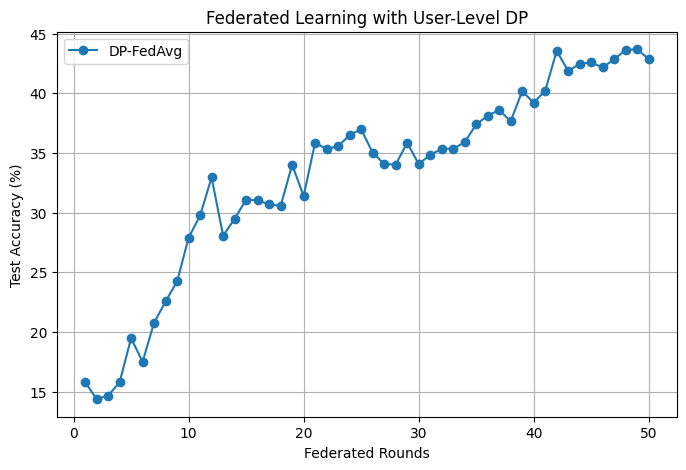

In [14]:
# --- Simulation Configuration ---
# Optimized hyperparameters for better accuracy
NUM_CLIENTS = 5
FL_ROUNDS = 50
FL_NOISE = 0.2
FL_CLIP = 1.0
LOCAL_STEPS = 5

print(f"\n--- Running FL Simulation (Clients={NUM_CLIENTS}, Rounds={FL_ROUNDS}) ---")

# 1. Setup Data and Clients
# Use a larger subset (e.g. 10,000 or more) for better stability
subset_indices = list(range(0, 10000))
# Ensure 'trainset' matches your variable name from previous cells
train_subset = torch.utils.data.Subset(trainset, subset_indices)

# Split train_subset into NUM_CLIENTS chunks and create SimpleFLClient instances
lengths = [len(train_subset) // NUM_CLIENTS] * NUM_CLIENTS
client_chunks = torch.utils.data.random_split(train_subset, lengths)
clients = [SimpleFLClient(DataLoader(chunk, batch_size=64, shuffle=True))
           for chunk in client_chunks]

# 2. Initialize Global Model
global_model = get_pretrained_model_for_cifar()
fl_accuracies = []

# 3. Federated Learning Loop
for round_idx in range(FL_ROUNDS):
    local_models = []
    
    # TODO: A. Local Training
    for client in clients:
        local_model = client.train(global_model,
                                   steps=LOCAL_STEPS,
                                   lr=0.01)
        local_models.append(local_model)

    # TODO: B. DP Aggregation
    global_model = server_aggregate(
        global_model,
        local_models,
        noise_multiplier=FL_NOISE,
        clip_norm=FL_CLIP
    )

    # TODO: C. Evaluation
    global_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            outputs = global_model(data)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    acc = 100 * correct / total
    fl_accuracies.append(acc)

    print(f"Round {round_idx+1}/{FL_ROUNDS} | Global Acc: {acc:.2f}%")

# Plot Results
plt.figure(figsize=(8, 5))
plt.plot(range(1, FL_ROUNDS + 1), fl_accuracies, marker='o', label='DP-FedAvg')
plt.xlabel('Federated Rounds')
plt.ylabel('Test Accuracy (%)')
plt.title('Federated Learning with User-Level DP')
plt.grid(True)
plt.legend()
plt.show()

## Part 6.4: Critical Analysis & Discussion

Now that you have implemented and observed both **Centralized DP-SGD** (Item-Level Privacy) and **Federated Learning with DP** (User-Level Privacy), answer the following questions to compare the two approaches.

### Question 4: User-Level vs. Item-Level Privacy
1.  **Scope of Protection:** In Part 2 (Centralized DP-SGD), we clipped the gradient of every *sample*. In Part 6 (Federated), we clipped the update of every *client*.
    * If a specific client has a unique dataset (e.g., photos of a rare object), which method (Centralized or Federated) offers better protection for that *specific* object? Why?
    * Which method better conceals the fact that the client *participated* in the training at all?

2.  **Utility & Convergence:**
    * Compare the convergence speed and final accuracy of the Federated model vs. the Centralized DP model.
    * Why is the "Noise-to-Signal" ratio typically worse in Federated Learning when $N$ (number of clients) is small (e.g., 5), compared to Centralized learning where $N$ (number of samples) is large (e.g., 50,000)?

3.  **The "Straggler" Problem (Thought Experiment):**
    * In our simulation, all clients computed updates instantly. In a real-world scenario with millions of phones, some devices are slow or drop out. If we drop the bottom 10% of updates, how might that bias the model? (Hint: Consider if the "slow" devices are older phones owned by a specific demographic).

**Your Answer:**
1. Centralized DP protects individual samples and Federated DP protects entire clients and if a client has a unique dataset then Federated DP better protects participation and Centralized DP better protects a single specific image

2. Federated learning converges slower because of fewer aggregation events and higher noise to signal ratio and small number of clients and then N (clients) is small and noise dominates.

3. If slow devices are systematically excluded like older phones owned by elderly users then the model becomes biased toward fast device demographics so this introduces representation bias.